In [1]:
import pandas as pd
import requests
from rdkit import Chem
from rdkit.Chem import Descriptors, QED
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:


def get_smiles_from_pubchem(url):
    """
    Extracts CID from the PubChem URL and fetches the Canonical SMILES.
    """
    try:
        # Extract CID from the URL (e.g., .../compound/65036 -> 65036)
        cid = str(url).strip().split('/')[-1]
        
        # PubChem PUG REST API URL for Canonical SMILES
        api_url = f"https://pubchem.ncbi.nlm.nih.gov/rest/pug/compound/cid/{cid}/property/CanonicalSMILES/TXT"
        
        # Fetch data
        response = requests.get(api_url, timeout=10)
        if response.status_code == 200:
            print(f"Fetched SMILES for CID {cid}")
            return response.text.strip()
        else:
            print(f"Failed to fetch SMILES for CID {cid}, status code: {response.status_code}")
            return None
    except Exception as e:
        print(f"Error fetching SMILES for {url}: {e}")
        return None
def calc_extended_properties(smiles):
    """Calculates Lipinski rules + TPSA, Rotatable Bonds, and QED."""
    if not smiles:
        return None
    
    mol = Chem.MolFromSmiles(smiles)
    if not mol:
        return None

    # Lipinski Properties
    mw = Descriptors.MolWt(mol)
    logp = Descriptors.MolLogP(mol)
    hbd = Descriptors.NumHDonors(mol)
    hba = Descriptors.NumHAcceptors(mol)
    
    # Extended Properties
    tpsa = Descriptors.TPSA(mol)
    rot_bonds = Descriptors.NumRotatableBonds(mol)
    qed_score = QED.qed(mol) # Float from 0 to 1

    # Rules Checks
    pass_mw = mw <= 500
    pass_logp = logp <= 5
    pass_hbd = hbd <= 5
    pass_hba = hba <= 10
    
    # Count passed rules (Lipinski)
    rules_passed = sum([pass_mw, pass_logp, pass_hbd, pass_hba])
    
    return {
        'MW': mw, 'LogP': logp, 'HBD': hbd, 'HBA': hba,
        'TPSA': tpsa, 'Rotatable_Bonds': rot_bonds, 'QED_Score': qed_score,
        'Pass_MW': pass_mw, 'Pass_LogP': pass_logp, 
        'Pass_HBD': pass_hbd, 'Pass_HBA': pass_hba,
        'Lipinski_Rules_Passed': rules_passed
    }

In [3]:
# --- Main Execution ---

# 1. Load the dataset (adjust filename as necessary)
filename = 'Lipid Lowering Herbs with SMILE.xlsx'
# Note: The file seems to have 2 header rows to skip based on inspection
df = pd.read_excel(filename, skiprows=2, index_col=0)
df.reset_index(inplace=True, drop = True)



In [4]:
print("Fetching SMILES codes... this may take a moment.")

# 2. Extract SMILES (Apply the function to the Link column)
# Ensure we use the correct column name 'SIMILE Code Link'
df['SMILES'] = df['SIMILE Code Link'].apply(get_smiles_from_pubchem)


Fetching SMILES codes... this may take a moment.
Fetched SMILES for CID 65036
Fetched SMILES for CID 9576089
Fetched SMILES for CID 5318517
Fetched SMILES for CID 9848024
Fetched SMILES for CID 445858
Fetched SMILES for CID 10922465
Fetched SMILES for CID 644019
Fetched SMILES for CID 11132454
Fetched SMILES for CID 3082459
Fetched SMILES for CID 5281228
Fetched SMILES for CID 1548943
Fetched SMILES for CID 49798103
Fetched SMILES for CID 119034
Fetched SMILES for CID 44560847
Fetched SMILES for CID 14287397
Fetched SMILES for CID 969516
Fetched SMILES for CID 5280863
Fetched SMILES for CID 5280343
Fetched SMILES for CID 439246
Fetched SMILES for CID 5281605
Fetched SMILES for CID 57403926
Fetched SMILES for CID 10196837
Fetched SMILES for CID 165558
Fetched SMILES for CID 1794427
Fetched SMILES for CID 5280633
Fetched SMILES for CID 9798666
Fetched SMILES for CID 6443484
Fetched SMILES for CID 5281717
Fetched SMILES for CID 476856
Fetched SMILES for CID 10146
Fetched SMILES for CID 10

In [5]:
print("Calculating Lipinski Rules...")

print("2. Calculating Drug-Likeness Properties...")
# Apply calculation and expand to columns
props = df['SMILES'].apply(calc_extended_properties).apply(pd.Series)
df_final = pd.concat([df, props], axis=1)

# Save the comprehensive data
df_final.to_csv('Bioactive_Analysis_Full.csv', index=False)
print("   Data saved to 'Bioactive_Analysis_Full.csv'")

Calculating Lipinski Rules...
2. Calculating Drug-Likeness Properties...
   Data saved to 'Bioactive_Analysis_Full.csv'


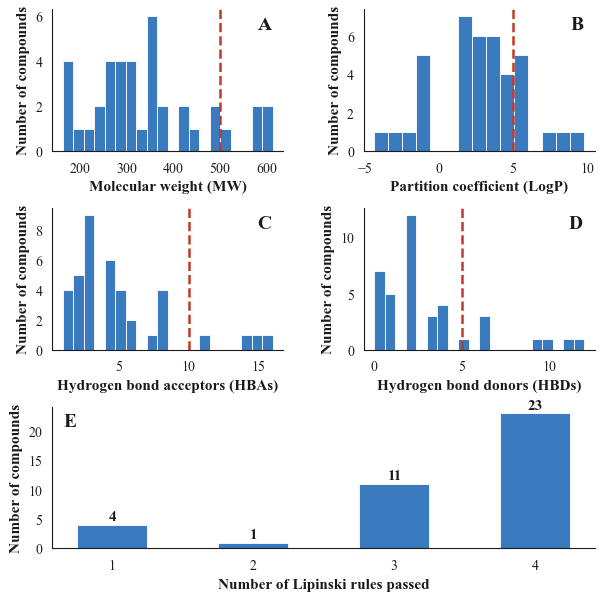

Visualization complete. Saved as 'Bioactive_Analysis_Charts_Fixed.png'


In [6]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

df_final = pd.read_csv('Bioactive_Analysis_Full.csv')

# Set style
sns.set_style("white")
plt.rcParams.update({
    'figure.max_open_warning': 0,
    'text.color': '#1a1a1a',
    'axes.labelcolor': '#1a1a1a',
    'xtick.color': '#1a1a1a',
    'ytick.color': '#1a1a1a',
    'axes.edgecolor': '#1a1a1a',
    'font.size': 11,
    'axes.labelsize': 11,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'font.family': 'serif',           # ← use serif family
    'font.serif': 'Times New Roman',  # ← set to Times New Roman
})

fig = plt.figure(figsize=(7, 7))
gs = gridspec.GridSpec(3, 2, figure=fig, hspace=0.4, wspace=0.35)

ax_A = fig.add_subplot(gs[0, 0])
ax_B = fig.add_subplot(gs[0, 1])
ax_C = fig.add_subplot(gs[1, 0])
ax_D = fig.add_subplot(gs[1, 1])
ax_E = fig.add_subplot(gs[2, :])

bar_color = '#3a7abf'
ref_color = '#c0392b'
label_bg  = '#ffffff'

def add_panel_label(ax, letter, x=0.95, ha='right'):
    ax.text(x, 0.95, letter, transform=ax.transAxes,
            fontsize=14, fontweight='bold', va='top', ha=ha,
            color='#1a1a1a',
            bbox=dict(boxstyle='round,pad=0.15', facecolor=label_bg,
                      edgecolor='none', alpha=0.85))

# --- Panel A: Molecular Weight ---
ax_A.hist(df_final['MW'].dropna(), bins=20, color=bar_color, edgecolor='white', linewidth=0.6)
ax_A.axvline(500, color=ref_color, linewidth=1.8, linestyle='--', label='MW = 500')
ax_A.set_xlabel('Molecular weight (MW)', fontweight='semibold')
ax_A.set_ylabel('Number of compounds', fontweight='semibold')
add_panel_label(ax_A, 'A')
sns.despine(ax=ax_A)

# --- Panel B: LogP ---
ax_B.hist(df_final['LogP'].dropna(), bins=15, color=bar_color, edgecolor='white', linewidth=0.6)
ax_B.axvline(5, color=ref_color, linewidth=1.8, linestyle='--', label='LogP = 5')
ax_B.set_xlabel('Partition coefficient (LogP)', fontweight='semibold')
ax_B.set_ylabel('Number of compounds', fontweight='semibold')
add_panel_label(ax_B, 'B')
sns.despine(ax=ax_B)

# --- Panel C: Hydrogen Bond Acceptors ---
ax_C.hist(df_final['HBA'].dropna(), bins=20, color=bar_color, edgecolor='white', linewidth=0.6)
ax_C.axvline(10, color=ref_color, linewidth=1.8, linestyle='--', label='HBA = 10')
ax_C.set_xlabel('Hydrogen bond acceptors (HBAs)', fontweight='semibold')
ax_C.set_ylabel('Number of compounds', fontweight='semibold')
add_panel_label(ax_C, 'C')
sns.despine(ax=ax_C)

# --- Panel D: Hydrogen Bond Donors ---
ax_D.hist(df_final['HBD'].dropna(), bins=20, color=bar_color, edgecolor='white', linewidth=0.6)
ax_D.axvline(5, color=ref_color, linewidth=1.8, linestyle='--', label='HBD = 5')
ax_D.set_xlabel('Hydrogen bond donors (HBDs)', fontweight='semibold')
ax_D.set_ylabel('Number of compounds', fontweight='semibold')
add_panel_label(ax_D, 'D')
sns.despine(ax=ax_D)

# --- Panel E: Lipinski Pass Count ---
lipinski_counts = df_final['Lipinski_Rules_Passed'].value_counts().sort_index()
bars = ax_E.bar(lipinski_counts.index.astype(str), lipinski_counts.values,
                color=bar_color, edgecolor='white', linewidth=0.6, width=0.5)

for bar, count in zip(bars, lipinski_counts.values):
    ax_E.text(bar.get_x() + bar.get_width() / 2,
              bar.get_height() + max(lipinski_counts.values) * 0.01,
              str(count), ha='center', va='bottom',
              fontsize=11, fontweight='bold', color='#1a1a1a')

ax_E.set_xlabel('Number of Lipinski rules passed', fontweight='semibold')
ax_E.set_ylabel('Number of compounds', fontweight='semibold')
add_panel_label(ax_E, 'E', x=0.02, ha='left')
sns.despine(ax=ax_E)

plt.savefig('Bioactive_Analysis_Charts_Fixed.png', dpi=800, bbox_inches='tight')
plt.show()

print("Visualization complete. Saved as 'Bioactive_Analysis_Charts_Fixed.png'")